In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182778, 8]) torch.Size([182778])
torch.Size([22633, 8]) torch.Size([22633])
torch.Size([22735, 8]) torch.Size([22735])


In [5]:
for x,y in zip(Xtr[:5], Ytr[:5]):
  print(''.join(itos[i.item()] for i in x), '->', itos[y.item()])

........ -> e
.......e -> m
......em -> m
.....emm -> a
....emma -> .


In [6]:
# -----------------------------------------------------------------------------------------------
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []
  
# -----------------------------------------------------------------------------------------------
class Embedding:
  def __init__(self,num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  def parameters(self): 
    return [self.weight]
  
# -----------------------------------------------------------------------------------------------
class FlattenConsecutive: # Naming differently cz pytorch flatten works differently
  def __init__(self, n):
    self.n = n
  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T // self.n, C * self.n) # flatten the last n dimensions
    if x.shape[1] == 1:
      x = x.squeeze(1) # remove the second dimension if it is 1
    self.out = x
    return self.out
  
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Sequential:
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [7]:
torch.manual_seed(42)

In [8]:
# original network
# n_embd = 10 # the dimensionality of the character embedding vectors
# n_hidden = 300 # the number of neurons in the hidden layer of the MLP
# model = Sequential([
#   Embedding(vocab_size, n_embd),
#   FlattenConsecutive(8), Linear(n_embd * 8, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#   Linear(n_hidden, vocab_size),
# ])

# hierarchical network
# n_embd = 24 # the dimensionality of the character embedding vectors
# n_hidden = 128 # the number of neurons in the hidden layer of the MLP
# model = Sequential([
#   Embedding(vocab_size, n_embd),
#   FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#   FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#   FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#   Linear(n_hidden, vocab_size),
# ])
n_embd = 10
n_hidden = 68 # To keep the number of parameters the same as the original network(MLP)

# C = torch.randn((vocab_size, n_embd)) # embedding matrix (vocab_size x n_embd)
# layers = [
#     Embedding(vocab_size, n_embd),
#     Flatten(),
#     Linear(n_embd*block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#     Linear(n_hidden, vocab_size),
# ]

model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2),Linear(n_embd*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2),Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])


# parameter init
with torch.no_grad():
#   model.layers[-1].weight *= 0.1 # last layer make less confident
    model.layers[0].weight *= 0.1 # first layer make less confident

# parameters = model.parameters()
# parameters = [p for layer in layers for p in layer.parameters()]
parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

22397


In [34]:
ix = torch.randint(0,Xtr.shape[0],(4,)) # random batch of indices
Xb, Yb = Xtr[ix], Ytr[ix] # batch of examples
logits = model(Xb) # forward pass
Xb

tensor([[ 0,  0,  0,  0, 26,  1,  8, 13],
        [ 0,  0,  0, 13,  1, 11,  5, 14],
        [ 0,  0,  0,  8, 15, 12, 12,  5],
        [ 0,  0,  0,  0,  0,  0,  0, 18]])

In [35]:
for layer in model.layers:
  print(layer.__class__.__name__,":", tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1d : (4, 4, 68)
Tanh : (4, 4, 68)
FlattenConsecutive : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1d : (4, 2, 68)
Tanh : (4, 2, 68)
FlattenConsecutive : (4, 136)
Linear : (4, 68)
BatchNorm1d : (4, 68)
Tanh : (4, 68)
Linear : (4, 27)


In [15]:
(torch.randn(4,4,20) @ torch.randn(20,200)).shape

torch.Size([4, 4, 200])

- In a matrix multiplication, all the dimensions except the last one of the 1st matrix and the 1st one of the 2nd matrix is preserved. 
- `(1 2) (3 4) (5 6) (7 8)` -> Now the 8 char context will be divided into 5 batches of bigrams so that they can be processed in parallel.
- So 1st batch dim has size 4(4 examples) and 2nd batch dim has size 4(4 bigrams in each example) and each char having an embedding of size 10. So this makes the total size of the matrix `4x4x20`

In [18]:
e = torch.randn(4, 8, 10) # goal: want this to be (4,4,20) where consec 10D vectors are concatenated
explicit = torch.cat([e[:,::2,:], e[:,1::2,:]], dim=2) # (4,4,20) ---> concating, 0 & 1, 2 & 3, 4 & 5, 6 & 7 and so on
explicit.shape

torch.Size([4, 4, 20])

In [19]:
(e.view(4,4,20) == explicit).all() # check if the two are equal

tensor(True)

- So `e.view(4,4,20)` gives the same matrix which we got by explicit concatenation.

In [36]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix] # batch of input and target

    # forward pass
    # emb = C[Xb] # (batch_size, block_size, n_embd)
    # x = emb.view(emb.shape[0], -1) # (batch_size, block_size * n_embd)
    # x = Xb
    # for layer in layers:
    #     x = layer(x)
    # logits = x # (batch_size, vocab_size)
    logits = model(Xb) # (batch_size, vocab_size)
    loss = F.cross_entropy(logits, Yb) # cross-entropy loss

    # backward pass
    for layer in model.layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data -= 0.1 * p.grad
    
    # track stats
    lossi.append(loss.log10().item())
    if i % 10000 == 0:
        print(f"{i:7d}/{max_steps}: {loss.item():.4f}")  

      0/200000: 3.4618
  10000/200000: 2.5540
  20000/200000: 2.6288
  30000/200000: 2.0301
  40000/200000: 1.9454
  50000/200000: 1.9335
  60000/200000: 2.3759
  70000/200000: 2.1778
  80000/200000: 1.9549
  90000/200000: 1.9594
 100000/200000: 1.7429
 110000/200000: 1.8652
 120000/200000: 1.9338
 130000/200000: 1.9832
 140000/200000: 2.0956
 150000/200000: 1.9636
 160000/200000: 1.9558
 170000/200000: 1.4307
 180000/200000: 2.4720
 190000/200000: 2.4542


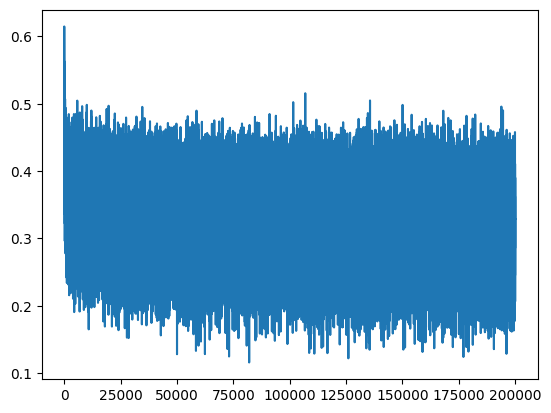

In [10]:
plt.plot(lossi);

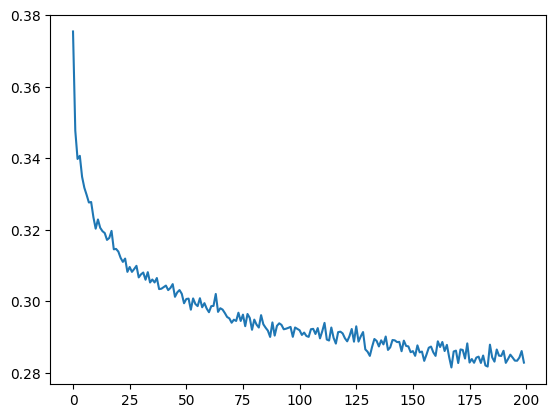

In [37]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(dim=1)); # plot the average loss over each 1000 steps

In [38]:
for layer in model.layers:
    layer.training = False # set to eval mode

In [39]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9097392559051514
val 2.2975003719329834


In [40]:
# sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

aahrie.
danaya.
amajah.
gritary.
akoaher.
adelli.
kaleyanna.
loan.
annal.
izarielle.
aleani.
tysha.
yosephin.
kalethe.
jemereli.
ameiki.
revin.
julia.
siak.
brittelyn.


- If we don't set the training mode of the layers to be `False`, During inference,as we are passing single input instead of batch, batchnorm layer outputs `nan` as var of a single number is `nan`
 
- Then the cell above produces an error